# Feynman rules of the Standard Model with `feynlag`

This notebook walks through **feynlag**'s pipeline stage by stage: declare
symmetries and fields, write the Lagrangian, check it, break the symmetry,
diagonalize, and extract Feynman rules — using the electroweak sector of the
Standard Model as the worked example. It ends with a guide to extending the
model to a BSM scenario.

Every cell below is executed live against the actual library — nothing here
is hand-typed output. All conventions (metric signature, `P_L`, the sign of
`D_μ`, the explicit `1/√2` in VEVs, vertex normalization) are fixed once in
[`CONVENTIONS.md`](../CONVENTIONS.md); that file is the source of truth if a
sign looks unfamiliar.

**What we're building**: an `SU(2)_L × U(1)_Y` Higgs doublet with its
potential and covariant kinetic term — enough to extract the Higgs
self-couplings, gauge-boson masses, the Weinberg rotation, and every
`hVV`/`hhVV`/Goldstone vertex.

In [ ]:
import sympy as sp
from feynlag import (
    Bilinear, DiracGamma, Dmu, ExternalParameter, InternalParameter,
    Lagrangian, Model, Rotation, SU2, Scalar, U1, WeylFermion,
    conjugate_pair, cubic_couplings, dag, diracPL, diracPR,
    extract_fermion_vertices, fermion_feynman_rule, fermion_gauge_current,
    fermion_mass_matrix, latex_feynman_table, quartic_couplings,
    rotation_2x2,
)

sp.init_printing()

## 1. Declare the symmetries and parameters

- `SU2`/`U1` are `GaugeGroup`s carrying explicit generator matrices (`σᵃ/2`
  for SU(2)); they build their own gauge-boson fields on demand.
- **`ExternalParameter`** is a number you feed in from experiment — it needs
  a `value` for benchmarking and later UFO export.
- **`InternalParameter`** is a symbol whose defining expression is *derived*
  later (here, by the tadpole condition in §6). `unit_dim` is the mass
  dimension, used by the dimension-≤-4 invariance check.
- `positive=True` lets SymPy simplify `sqrt` expressions involving `v`,
  `gw`, `g1` without spurious branch-cut assumptions (the "positive dummy
  symbols" rule in `CONVENTIONS.md`).

In [ ]:
gw = ExternalParameter("gw", 0.6535, positive=True)
g1 = ExternalParameter("g1", 0.3580, positive=True)
SU2L, U1Y = SU2("SU2L", coupling=gw), U1("U1Y", coupling=g1)

v   = ExternalParameter("v", 246.0, positive=True, unit_dim=1)
lam = ExternalParameter("lam", 0.129)
mu2 = InternalParameter("mu2", unit_dim=2)   # will be *derived*, not set

gw, g1, v, lam, mu2

(ExternalParameter('gw'),
 ExternalParameter('g1'),
 ExternalParameter('v'),
 ExternalParameter('lam'),
 InternalParameter('mu2'))

## 2. Declare the fields

`reps` assigns representations: `2` is the SU(2) doublet, `1/2` the
hypercharge. This alone generates the two component symbols `Gp` (complex,
the charged Goldstone-to-be) and `H0` (complex, the neutral component) plus a
conjugate registry that `dag(H)` uses.

Register the vacuum expectation value on the neutral component only — charge
conservation forbids a VEV on `Gp`.

In [ ]:
H = Scalar("H", reps={SU2L: 2, U1Y: sp.Rational(1, 2)},
           component_names=["Gp", "H0"])
H.expand_vev({H.components[1]: v})   # H0 -> (v + h + i*G0) / sqrt(2)

H.components, H.vev_expansions[H.components[1]]

## 3. Write the Lagrangian — FeynRules style

feynlag doesn't auto-generate the potential; you write it with library
building blocks, and the library checks it's legal.

- `dag(H)` returns the row-vector Hermitian conjugate; `H.mat` is the column
  of components — their product is the standard invariant bilinear.
- `Dmu(H)` reads `H.reps` and automatically pulls in **both** `SU2L` and
  `U1Y` gauge bosons (created lazily the first time) with the correct
  generator matrices — `D_μ = ∂_μ − i g Tᵃ Aᵃ_μ`.
- Lagrangian terms are tagged by **sector** (`kinetic`, `potential`,
  `yukawa`, `gauge`, `other`); hermiticity is checked per sector, and you can
  extract vertices from one sector at a time.

In [ ]:
HdH = (dag(H) * H.mat)[0]          # H^dagger H, an SU(2)xU(1) invariant scalar
V   = -mu2.s * HdH + lam.s * HdH**2

DH = Dmu(H)                         # covariant derivative
L = Lagrangian()
L.add((dag(DH) * DH)[0], sector="kinetic")
L.add(-V, sector="potential")       # L contains -V, per CONVENTIONS.md

V

## 4. Assemble the Model and check invariance

`SU2L.bosons("W")` / `U1Y.bosons("B")` materialize the gauge-boson `Field`s
(three real components `W_1, W_2, W_3` and one `B`) — the same objects
`Dmu(H)` used internally, so they must be listed explicitly as model fields.

`check_invariance()` is a real check: for every term it verifies (a) gauge
invariance under each declared group by an infinitesimal variation
`δφ = iαᵀφ`, requiring every generator's coefficient to vanish — including
through the `Dmu`-built kinetic term, since `∂_μ` commutes with a global
transformation; (b) hermiticity per sector; (c) mass dimension ≤ 4.

In [ ]:
model = Model("SM-EW", gauge_groups=[SU2L, U1Y],
              fields=[H, SU2L.bosons("W"), U1Y.bosons("B")],
              parameters=[gw, g1, v, lam, mu2], lagrangian=L)

report = model.check_invariance()
report

InvarianceReport(8 checks, OK)

## 5. Break the symmetry: tadpoles and masses

`solve_tadpoles` evaluates `V` on the vacuum, differentiates with respect to
each registered VEV (`∂V/∂v = 0`), solves for `mu2`, and **registers the
solution on the `InternalParameter`** — `mu2.expr` becomes `lam*v**2`. Every
later stage (mass matrices, the physical Lagrangian, UFO export)
automatically substitutes it.

Scalar masses come from the Hessian of `V` at the vacuum.

In [ ]:
tadpole_solution = model.solve_tadpoles([mu2])
tadpole_solution

In [ ]:
h, G0 = sp.Symbol("H0_r", real=True), sp.Symbol("H0_i", real=True)
m_h_squared = model.mass_matrix([h])[0, 0]
m_h_squared

## 6. Gauge-boson masses and the Weinberg rotation

Gauge-boson masses come from the *kinetic* sector evaluated on the vacuum
(scalars are constant there, so all `∂_μ` terms vanish and only the
`g²v²·(gauge field)²` piece survives). `W1, W2` decouple from `W3, B` at this
order; the `(W3, B)` block is the familiar singular matrix whose non-zero
eigenvalue is `m_Z²` and whose zero eigenvalue is the photon.

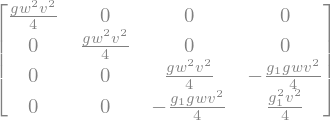

In [ ]:
W1, W2, W3 = SU2L.bosons().components
B = U1Y.bosons().components[0]
M2_gauge = model.gauge_mass_matrix([W1, W2, W3, B])
M2_gauge

A `Rotation` is `new = R · old`; register it and every later
Lagrangian extraction rewrites the weak-basis fields for you.

- `rotation_2x2(θ)` is `[[cosθ, sinθ], [−sinθ, cosθ]]`; the minus sign on
  `thetaW` gives the textbook convention `Z = cosθ_W W³ − sinθ_W B`.
- `kind="unitary"` tells `Rotation` to use `R†` (not `Rᵀ`) as the inverse —
  needed for the complex combination `W± = (W1 ∓ iW2)/√2`.

In [ ]:
Z, A = sp.symbols("Z A", real=True)
thetaW = sp.atan(g1.s / gw.s)
model.rotate(Rotation([W3, B], [Z, A], rotation_2x2(-thetaW)))

Wp, Wm = sp.symbols("Wp Wm")
U_charged = sp.Matrix([[1, -sp.I], [1, sp.I]]) / sp.sqrt(2)
model.rotate(Rotation([W1, W2], [Wp, Wm], U_charged, kind="unitary"))

"rotations registered:", len(model.rotations)

('rotations registered:', 2)

## 7. Extract the Feynman rules

What happens inside `feynman_rules`:

1. `physical_lagrangian()` takes the full `L`, applies the vacuum shift
   (`H0 -> (v+h+iG0)/sqrt(2)`), substitutes the tadpole solution for `mu2`,
   then applies every registered `Rotation`'s substitution dict — all
   lazily cached.
2. Since the kinetic sector has `∂_μ` on every field, the result still
   contains `PartialMu` heads. These get Leibniz-expanded and sent to
   momentum space, `∂_μ φ → i·p(φ)·φ`, tagging each leg with its own
   symbolic momentum `p(φ)`.
3. `conjugate_map` rewrites `conjugate(Gp)` → the plain symbol `Gm` so the
   commuting-symbol extractor can see it as an ordinary field leg (`Gp`
   never got a VEV, so it stays a single complex physical field with its own
   antiparticle).
4. Every vertex gets the standard normalization
   `i × coefficient × ∏(leg multiplicities)!`.

**Dict keys are in SymPy's canonical sort order**, not the order you write
them in — look them up with a small helper (this is exactly what the test
suite does).

In [ ]:
Gp = H.components[0]
Gm, cmap = conjugate_pair(Gp, "Gm")
fields = [h, G0, Gp, Gm, Z, A, Wp, Wm]

rules = model.feynman_rules(fields, conjugate_map=cmap, simplifier=sp.simplify)

def rule(*flds):
    key = tuple(sorted(flds, key=lambda s: s.sort_key()))
    return rules[key]

f"{len(rules)} vertices extracted"

'38 vertices extracted'

In [ ]:
print("hWW    =", rule(h, Wp, Wm))       # i g^2 v/2 = i g m_W
print("hhWW   =", rule(h, h, Wp, Wm))    # i g^2/2
print("hZZ    =", rule(h, Z, Z))         # i (g^2+g'^2) v/2

hWW    = I*gw**2*v/2
hhWW   = I*gw**2/2
hZZ    = I*v*(g1**2 + gw**2)/2


A momentum-dependent vertex — `A G⁺ G⁻` (the scalar-QED photon
coupling) — carries the antisymmetric combination `p(Gp) − p(Gm)`, since it
comes from the derivative (kinetic) term rather than the potential.

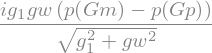

In [ ]:
rule(A, Gp, Gm)

If you want typed objects instead of a flat dict (useful for UFO
export or for grouping by vertex topology), use `model.vertices(...)` — same
arguments, returns `Vertex` objects classified into the closed catalog
`SSS, SSSS, VSS, VVS, VVSS, VVV, VVVV, FFS, FFV` by inspecting the spin
content of each leg.

In [ ]:
verts = model.vertices(fields, conjugate_map=cmap, simplifier=sp.simplify)
sorted({v.vertex_type for v in verts})

['SSS', 'SSSS', 'VSS', 'VVS', 'VVSS']

## 8. Pure-gauge self-couplings

Cubic/quartic pure-gauge self-couplings (`γW⁺W⁻`, `W⁺W⁻W⁺W⁻`, …) are *not*
produced by `feynman_rules` — they come directly from the group's structure
constants, since their Lorentz structure is universal. You supply the
mixing matrix `U` from adjoint components `(W1, W2, W3)` to the physical
bosons `(W+, W-, Z, A)`.

`cubic_couplings`/`quartic_couplings` return the coupling **with the
vertex's overall `i` already included** (the same convention `feynman_rule`
uses, and what `write_ufo` expects verbatim) — so `g(A,W⁺,W⁻)` below comes
out as `i·e`, not bare `e`. We print the magnitude to compare against the
textbook value directly.

In [ ]:
cw, sw = gw.s / sp.sqrt(gw.s**2 + g1.s**2), g1.s / sp.sqrt(gw.s**2 + g1.s**2)
U_mix = sp.Matrix([
    [1 / sp.sqrt(2), 1 / sp.sqrt(2), 0, 0],
    [sp.I / sp.sqrt(2), -sp.I / sp.sqrt(2), 0, 0],
    [0, 0, cw, sw],
])
triple = cubic_couplings(SU2L, physical=[Wp, Wm, Z, A], U=U_mix)

g_AWW = sp.simplify(triple[(A, Wp, Wm)])
g_ZWW = sp.simplify(triple[(Z, Wp, Wm)])
e = gw.s * sw   # = g sin(theta_W), the electric charge

print("g(A,W+,W-) =", g_AWW, " -> |g(A,W+,W-)| - e  =", sp.simplify(sp.Abs(g_AWW) - e))
print("g(Z,W+,W-) =", g_ZWW, " -> |g(Z,W+,W-)| - g*cos(theta_W) =",
      sp.simplify(sp.Abs(g_ZWW) - gw.s * cw))

g(A,W+,W-) = I*g1*gw/sqrt(g1**2 + gw**2)  -> |g(A,W+,W-)| - e  = 0
g(Z,W+,W-) = I*gw**2/sqrt(g1**2 + gw**2)  -> |g(Z,W+,W-)| - g*cos(theta_W) = 0


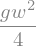

In [ ]:
quartic = quartic_couplings(SU2L, physical=[Wp, Wm, Z, A], U=U_mix)
sp.simplify(quartic[(Wp, Wm, Wp, Wm)])   # WWWW quartic

## 9. Adding fermions: the SM lepton sector

Chiral fermions use a **separate track** from the scalar/gauge extractor
above: a fermion sandwich `ψ̄ Γ ψ` is a c-number "atom", not a product of
commuting symbols, so it can't go through the same `Poly`-based extractor.

- `WeylFermion(name, reps=..., chirality=..., nflavors=...)` declares a
  chiral multiplet; its gauge components are `IndexedBase` objects (one
  `Indexed(base, flavor)` per flavor), not plain `Symbol`s.
- `Bilinear(ψ̄[i], Γ, χ[j])` is the opaque atom representing a fermion
  sandwich, where `Γ` is a Dirac structure built from `diracPL`/`diracPR`/
  `DiracGamma(mu)*diracPL` (see [`CONVENTIONS.md`](../CONVENTIONS.md) for
  the `P_L=(1-γ₅)/2` convention).
- `fermion_gauge_current(field, flavor_index)` builds the interaction part
  of `i ψ̄ γ^μ D_μ ψ` for you — the analogue of `Dmu` for fermions.

**Two things this section does *not* verify** (documented gaps, not silent
omissions): `check_invariance()`'s hermiticity check is *skipped* (not
falsely failed) for any sector containing a `Bilinear`, since verifying
`[ψ̄₁Γψ₂]† = ψ̄₂Γ̄ψ₁` needs Dirac-conjugation identities not yet
implemented — write `+ h.c.` terms explicitly, as done below. And
discrete-symmetry invariance checking (`S3`/`ZN`) doesn't yet cover fermion
multiplets either. **Gauge invariance and mass-dimension checking of
fermion terms, however, are fully implemented and exercised below.**

In [ ]:
Ll = WeylFermion("Ll", reps={SU2L: 2, U1Y: -sp.Rational(1, 2)},
                 chirality="L", nflavors=3, component_names=["nuL", "eL"])
eR = WeylFermion("eR", reps={U1Y: -1}, chirality="R", nflavors=3,
                 component_names=["eR"])

Ll.components, eR.components

The Yukawa Lagrangian, written by hand exactly like the potential
was — a scalar factor times a `Bilinear`, plus its hermitian conjugate
(built explicitly, since it can't be auto-derived yet):
`L_Yuk = -Ye[i,j] L̄_i H e_R[j] + h.c.`, with the `P_R` sandwich carrying the
right-handed projection and `Ye` a general flavor matrix.

In [ ]:
i, j = sp.symbols("i j", integer=True)
Ye = sp.IndexedBase("Ye")
nuLbar, eLbar = Ll.bar_components
eRc, eRbar = eR.components[0], eR.bar_components[0]
Gp, H0 = H.components   # (re)bind: Gp was set in §7, H0 not yet named

LYuk = -(Ye[i, j] * Gp * Bilinear(nuLbar[i], diracPR, eRc[j])
         + Ye[i, j] * H0 * Bilinear(eLbar[i], diracPR, eRc[j]))
LYuk += -(sp.conjugate(Ye[i, j]) * sp.conjugate(Gp)
          * Bilinear(eRbar[j], diracPL, Ll.components[0][i])
          + sp.conjugate(Ye[i, j]) * sp.conjugate(H0)
          * Bilinear(eRbar[j], diracPL, Ll.components[1][i]))

current = fermion_gauge_current(Ll, i) + fermion_gauge_current(eR, i)
"Yukawa and gauge-current terms built"

'Yukawa and gauge-current terms built'

To add fermions to the model, build the **complete** Lagrangian
(reusing the exact same `DH`, `V` expressions from §3) and construct one
fresh `Model` with every field — this mirrors
[`examples/sm_scalar_gauge.py`](sm_scalar_gauge.py), which does the same
thing from the start rather than mutating the bosonic-only `model` from
§4 in place. The already-found tadpole solution and `Z`/`A`/`W±` rotations
are plain Python objects — reuse them directly.

In [ ]:
L_full = Lagrangian()
L_full.add((dag(DH) * DH)[0], sector="kinetic")
L_full.add(-V, sector="potential")
L_full.add(LYuk, sector="yukawa")
L_full.add(current, sector="yukawa")

model_leptons = Model("SM-EW-leptons", gauge_groups=[SU2L, U1Y],
                      fields=[H, Ll, eR, SU2L.bosons(), U1Y.bosons()],
                      parameters=[gw, g1, v, lam, mu2], lagrangian=L_full)

report = model_leptons.check_invariance()
report

InvarianceReport(14 checks, OK)

In [ ]:
model_leptons.solve_tadpoles([mu2])
for rot in model.rotations:      # reuse the Z/A and W+/W- rotations from §6
    model_leptons.rotate(rot)
"tadpoles solved, rotations applied"

'tadpoles solved, rotations applied'

### Lepton mass matrix

`fermion_mass_matrix` collects the coefficient of the
`Bilinear(ψ̄_a, Γ, χ_b)` sandwich at the vacuum — the Lagrangian mass term
is `−ψ̄ M χ`, so the returned matrix already has the right sign:
`M_e = Y_e v/√2`.

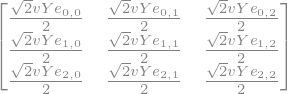

In [ ]:
M_e = fermion_mass_matrix(LYuk, eLbar, eRc, model_leptons.vacuum, 3, (i, j),
                          gamma=diracPR)
M_e

### Fermion Feynman rules

`model.physical_lagrangian(sector=...)` applies the vacuum shift, tadpole
solution, and every registered rotation to *any* sector — including
`"yukawa"` — so the h/G0-lepton couplings and the already-rotated gauge
currents come out of a single `extract_fermion_vertices` pass. Note the
Yukawa term carries **two** flavor indices (`Ye[i,j]` connects the
doublet's flavor `i` to `eR`'s flavor `j`), while the gauge currents are
flavor-diagonal (same index on both legs) — the lookup key must match.

In [ ]:
Gm, cmap = conjugate_pair(Gp, "Gm")
boson_fields = [h, G0, Gp, Gm, Z, A, Wp, Wm]

LYuk_phys = model_leptons.physical_lagrangian(sector="yukawa").xreplace(cmap)
table = extract_fermion_vertices(LYuk_phys, boson_fields)

mu = sp.Symbol("mu", integer=True)
gammaL = DiracGamma(mu) * diracPL
gammaR = DiracGamma(mu) * diracPR
nuL, eL = Ll.components

def fermion_rule(bar, gamma, field, boson):
    coeff = table[(bar, gamma, field)][1][(boson,)]
    return sp.simplify(fermion_feynman_rule(coeff, gamma, (boson,)))

print("h  e_L e_R ->", fermion_rule(eLbar[i], diracPR, eRc[j], h))
print("W+ nu  e   ->", fermion_rule(nuLbar[i], gammaL, eL[i], Wp))
print("Z  e_L e_L ->", fermion_rule(eLbar[i], gammaL, eL[i], Z))
print("Z  e_R e_R ->", fermion_rule(eRbar[i], gammaR, eRc[i], Z))
print("A  e_L e_L ->", fermion_rule(eLbar[i], gammaL, eL[i], A))
print("A  e_R e_R ->", fermion_rule(eRbar[i], gammaR, eRc[i], A))

h  e_L e_R -> -sqrt(2)*I*Ye[i, j]*PR/2
W+ nu  e   -> sqrt(2)*I*gw*gamma(mu)*PL/2
Z  e_L e_L -> I*(g1**2 - gw**2)*gamma(mu)*PL/(2*sqrt(g1**2 + gw**2))
Z  e_R e_R -> I*g1**2*gamma(mu)*PR/sqrt(g1**2 + gw**2)
A  e_L e_L -> -I*g1*gw*gamma(mu)*PL/sqrt(g1**2 + gw**2)
A  e_R e_R -> -I*g1*gw*gamma(mu)*PR/sqrt(g1**2 + gw**2)


The `h e_L e_R` rule, specialized to a single flavor with
`Y_e = √2 m_ℓ/v` (the diagonal-mass convention), reduces to the pinned
value `−i m_ℓ/v · P_R` (`+ h.c.`) — and the `W⁺νe`/`Z`/`γ` couplings above
match `i g/√2 · γ^μP_L`, the `g_Z(T³−Qs²_W)` pattern, and `∓ie` respectively,
all cross-checked in
[`tests/test_fermion_sector.py`](../tests/test_fermion_sector.py) (which
also covers `diagonalize_svd`/`diagonalize_takagi` for 3-generation mass
matrices and a toy type-I seesaw — not repeated here).

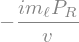

In [ ]:
m_ell = sp.Symbol("m_ell", positive=True)
hll_coeff = table[(eLbar[i], diracPR, eRc[j])][1][(h,)]
hll_rule = fermion_feynman_rule(hll_coeff, diracPR, (h,))
sp.simplify(hll_rule.subs(Ye[i, j], sp.sqrt(2) * m_ell / v.s))

## 10. Output: LaTeX tables and UFO export

`latex_feynman_table` produces a ready-to-paste `\begin{array}` table.

In [ ]:
preview = {k: rules[k] for k in list(rules)[:4]}
print(latex_feynman_table(preview))

\begin{array}{|c|c|}
\hline
\textbf{Interaction} & \textbf{Coefficient} \\
\hline
$A A Gm Gp$ & $\frac{2 i g_{1}^{2} gw^{2}}{g_{1}^{2} + gw^{2}}$ \\
\hline
$A Gm Gp Z$ & $\frac{i g_{1} gw \left(- g_{1}^{2} + gw^{2}\right)}{g_{1}^{2} + gw^{2}}$ \\
\hline
$A Gm H_{0 i} Wp$ & $- \frac{g_{1} gw^{2}}{2 \sqrt{g_{1}^{2} + gw^{2}}}$ \\
\hline
$A Gm H_{0 r} Wp$ & $\frac{i g_{1} gw^{2}}{2 \sqrt{g_{1}^{2} + gw^{2}}}$ \\
\hline
\end{array}


For a MadGraph-importable model directory, use
`feynlag.export.ufo.write_ufo(...)` — it needs a `UFOParticle` spec per
physical field (PDG code, spin, mass parameter name, color, charge). See
[`tests/test_ufo_export.py`](../tests/test_ufo_export.py) for a complete
worked call, including a numeric round-trip check that the exported `hWW`
coupling evaluates to `i g² v/2`.

## 11. Extending the SM: writing a BSM model

Every BSM model follows exactly the pipeline above; the only things that
change are *what you declare in §1–§3*. Worked templates already live in
[`examples/thdm.py`](thdm.py) (a second Higgs doublet, softly-broken `Z₂`)
and [`examples/thdm_s3.py`](thdm_s3.py) (a discrete `S₃` flavor symmetry
across three doublets) — read them alongside this checklist:

1. **New fields**: declare extra `Scalar`/`Fermion`/`GaugeBoson`s with their
   representations under your (possibly extended) symmetry groups. Extra
   gauge groups are just more `SU2`/`U1`/`SU3` objects passed to
   `gauge_groups=[...]`; a gauged extra `U(1)'` is created exactly like
   `U1Y` above.
2. **New symmetries**: for a discrete symmetry (softly-broken `Z₂` picking
   out Yukawa alignment in a 2HDM, or an `S₃` flavor symmetry across three
   doublets), instantiate `ZN(name, N)` or `S3()`, then
   `group.assign(irrep, *fields)`. `S3.doublet_product(...)` gives you the
   `2⊗2 = 1⊕1'⊕2` Clebsch–Gordan contractions to build invariant terms
   without doing the group theory by hand — `thdm_s3.py` builds its entire
   potential this way.
3. **Extend the potential/Yukawas**: write the new invariant contractions
   (`dag(H1)*H2.mat`, CG products, …) and add them to a `Lagrangian` sector.
   Call `model.check_invariance()` immediately — a forbidden term (wrong
   representation, missing `+ h.c.`, wrong discrete charge) fails loudly
   instead of silently producing wrong Feynman rules downstream.
4. **VEVs on every scalar that gets one**, then `solve_tadpoles([...])` for
   as many mass parameters as you have independent tadpole conditions. If
   the system is *over*-constrained (more tadpole equations than free mass
   parameters — the `thdm_s3.py` case), that's physical: it's forcing a
   vacuum alignment, visible as a residual condition on the VEV ratios after
   solving the others (exactly how `thdm_s3.py` recovers the `√3`
   alignment).
5. **Mass matrices grow with the field content**: `model.mass_matrix([...])`
   accepts any list of same-block fluctuation symbols — a 3×3 CP-even block
   for a 3HDM works identically to the SM's 1×1 above. For blocks too large
   to diagonalize in closed form (≥3×3 symbolic), don't call
   `sp.Matrix.eigenvects` directly; either parametrize a rotation and solve
   the off-diagonal conditions numerically at benchmark points, or export to
   UFO and diagonalize numerically downstream.
6. **Register every new rotation** the same way as `alpha`/`beta` in
   `thdm.py`'s CP-even block.
7. **Extract vertices exactly as in §7**, just with a longer `fields` list.
   Chiral fermions use a parallel "bilinear" track
   (`feynlag.Bilinear`, `fermion_gauge_current`,
   `extract_fermion_vertices`) since a fermion sandwich is a c-number atom,
   not a product of commuting symbols — §9 above works through the full
   SM-lepton case (Yukawa, gauge currents, mass matrix, Feynman rules,
   including how `check_invariance()` now covers fermion gauge invariance
   and mass dimension); see
   [`tests/test_fermion_sector.py`](../tests/test_fermion_sector.py) for the
   3-generation `diagonalize_svd`/`diagonalize_takagi` and seesaw pieces not
   repeated there.

The invariant is: nothing about `Model`, `check_invariance`,
`solve_tadpoles`, `mass_matrix`, `rotate`, or `feynman_rules` is
SM-specific — they operate purely on whatever fields, symmetries, and
Lagrangian terms you declared. Growing the model is additive, not a
rewrite. As a taste of step 1–2, here is the *declaration* half of a second
Higgs doublet (the full potential and pipeline is in `thdm.py`):

In [ ]:
H2 = Scalar("H2", reps={SU2L: 2, U1Y: sp.Rational(1, 2)},
            component_names=["H2p", "H20"])
v2 = ExternalParameter("v2", 246.0 * 0.31, positive=True, unit_dim=1)
H2.expand_vev({H2.components[1]: v2})

# a new SU(2)xU(1)-invariant mixed bilinear, available for the potential:
H1dH2 = (dag(H) * H2.mat)[0]
H1dH2